# Evaluation Results and Hypothesis Testing

## Zero-Shot Evaluation

### LLaVA

#### IMPORTING DATA

In [1]:
import json
file_path = '/Users/kristinafuji/scale-equity-nlp/llava_group_accuracy_results_all.json'
with open(file_path, 'r') as file:
    data_llava = json.load(file)

In [2]:
import pandas as pd
# Western vs Non-Western DataFrame
llava_western = pd.DataFrame([
    {"Group": "Western", "Correct": data_llava["Western"]["correct"], "Total": data_llava["Western"]["total"], "Accuracy": data_llava["Western"]["accuracy"]},
    {"Group": "Non-Western", "Correct": data_llava["Non-Western"]["correct"], "Total": data_llava["Non-Western"]["total"], "Accuracy": data_llava["Non-Western"]["accuracy"]}
])

# Continents DataFrame
continents_list_llava = []
for continent, stats in data_llava["Continents"].items():
    continents_list_llava.append({
        "Continent": continent,
        "Correct": stats["correct"],
        "Total": stats["total"],
        "Accuracy": stats["accuracy"]
    })

llava_continents = pd.DataFrame(continents_list_llava)

# Print both DataFrames
print("Western vs Non-Western:")
print(llava_western)
print("\nContinents:")
print(llava_continents)

Western vs Non-Western:
         Group  Correct  Total   Accuracy
0      Western     2195   2660  82.518797
1  Non-Western     2937   3710  79.164420

Continents:
       Continent  Correct  Total   Accuracy
0         Europe      231    248  93.145161
1  North America       24     29  82.758621
2        Oceania      260    279  93.189964
3           Asia      415    470  88.297872
4    Middle East      227    243  93.415638
5         Africa      161    176  91.477273
6  Latin America      209    240  87.083333


**Calculating Disparity for Continents and Western**

Western/Non-Western Accuracy Disparity: 3.35%
Continents Accuracy Disparity: 10.66%


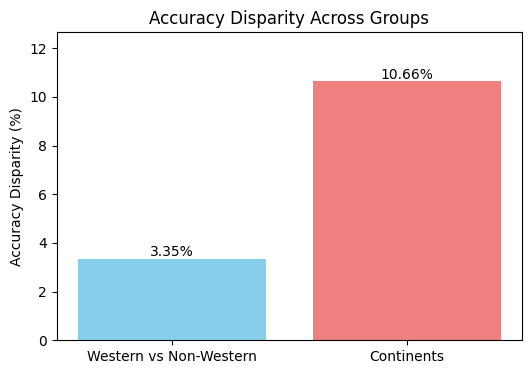

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

western_disparity = llava_western['Accuracy'].max() - llava_western['Accuracy'].min()
print(f"Western/Non-Western Accuracy Disparity: {western_disparity:.2f}%")

# Calculate disparity for Continents
continent_disparity = llava_continents['Accuracy'].max() - llava_continents['Accuracy'].min()
print(f"Continents Accuracy Disparity: {continent_disparity:.2f}%")

# Plotting
disparities = {
    'Western vs Non-Western': western_disparity,
    'Continents': continent_disparity
}

# Plot
plt.figure(figsize=(6,4))
plt.bar(disparities.keys(), disparities.values(), color=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy Disparity (%)')
plt.title('Accuracy Disparity Across Groups')

# Add labels on top of bars
for i, v in enumerate(disparities.values()):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontsize=10)

plt.ylim(0, max(disparities.values()) + 2)
plt.show()

In [4]:
import plotly.graph_objects as go

# Create a bar chart
fig = go.Figure()

# Add bars for disparities
fig.add_trace(go.Bar(
    x=list(disparities.keys()),
    y=list(disparities.values()),
    marker_color=['skyblue', 'lightcoral'],
    text=[f"{v:.2f}%" for v in disparities.values()],
    textposition='outside'
))

# Update layout
fig.update_layout(
    title='Accuracy Disparity Across Groups',
    xaxis_title='Groups',
    yaxis_title='Accuracy Disparity (%)',
    yaxis=dict(range=[0, max(disparities.values()) + 2]),
    height=400,
    width=600
)

# Show the plot
fig.show()

**Plotting Accuracies**

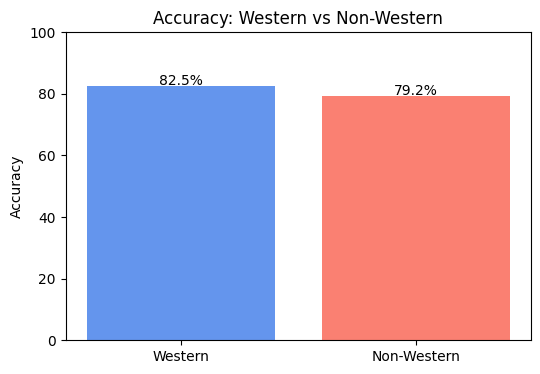

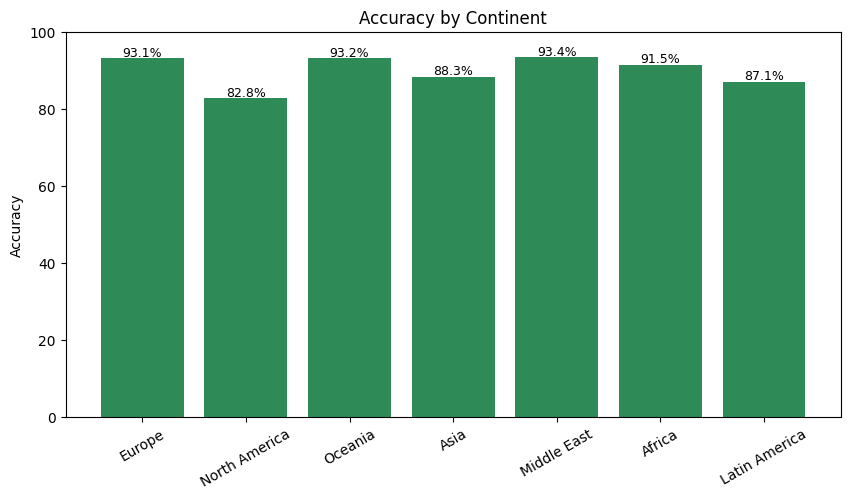

In [5]:
# Western vs Non-Western Accuracy 
tpr_western = llava_western[['Group', 'Accuracy']].copy()

# Continents Accuracies
tpr_continents = llava_continents[['Continent', 'Accuracy']].copy()

# Plot: Western vs Non-Western Accuracy
plt.figure(figsize=(6,4))
plt.bar(tpr_western['Group'], tpr_western['Accuracy'], color=['cornflowerblue', 'salmon'])
plt.ylabel('Accuracy')
plt.title('Accuracy: Western vs Non-Western')
for i, v in enumerate(tpr_western['Accuracy']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')
plt.ylim(0, 100)
plt.show()

# Plot: Continents TPR
plt.figure(figsize=(10,5))
plt.bar(tpr_continents['Continent'], tpr_continents['Accuracy'], color='seagreen')
plt.ylabel('Accuracy')
plt.title('Accuracy by Continent')
for i, v in enumerate(tpr_continents['Accuracy']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.show()



In [6]:
import plotly.graph_objects as go

# Western vs Non-Western Accuracy 
tpr_western = llava_western[['Group', 'Accuracy']].copy()

# Continents Accuracies
tpr_continents = llava_continents[['Continent', 'Accuracy']].copy()

# Plot: Western vs Non-Western Accuracy
fig1 = go.Figure()
fig1.add_trace(go.Bar(
    x=tpr_western['Group'],
    y=tpr_western['Accuracy'],
    marker_color=['lightblue', 'darkblue'],
    text=[f"{v:.1f}%" for v in tpr_western['Accuracy']],
    textposition='outside'
))
fig1.update_layout(
    title='Accuracy: Western vs Non-Western',
    xaxis_title='Group',
    yaxis_title='Accuracy',
    yaxis=dict(range=[0, 100]),
    height=400
)
fig1.show()

# Plot: Continents TPR
fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=tpr_continents['Continent'],
    y=tpr_continents['Accuracy'],
    marker_color='blue',
    text=[f"{v:.1f}%" for v in tpr_continents['Accuracy']],
    textposition='outside'
))
fig2.update_layout(
    title='Accuracy by Continent',
    xaxis_title='Continent',
    yaxis_title='Accuracy',
    xaxis=dict(tickangle=30),
    yaxis=dict(range=[0, 100]),
    height=500
)
fig2.show()

#### Z-TESTS AND PLOTS FOR LLAVA

**Is the difference in accuracy between groups statistically significant, or could it be random?**

In [3]:
from statsmodels.stats.proportion import proportions_ztest

# Counts of correct answers
correct = llava_western['Correct']  # Western, Non-Western

# Total questions per group
total = llava_western['Total']

# Two-proportion z-test
z_stat, p_value = proportions_ztest(count=correct, nobs=total)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant difference in accuracy.")
else:
    print("❌ No significant difference.")


Z-statistic: 3.3366
P-value: 0.0008
✅ Statistically significant difference in accuracy.


In [54]:
from itertools import combinations

comparison_results = []

# Iterate through combinations of continents
for continent1, continent2 in combinations(llava_continents.iterrows(), 2):
    total_c1 = llava_continents['Total'][continent1[0]]
    correct_c1 = llava_continents['Correct'][continent1[0]]
    total_c2 = llava_continents['Total'][continent2[0]]
    correct_c2 = llava_continents['Correct'][continent2[0]]
    z_stat, p_value = proportions_ztest(count=[correct_c1, correct_c2], nobs=[total_c1, total_c2])
    
    # Append the results to the list
    comparison_results.append({
        "Continent 1": continent1[1]['Continent'],
        "Continent 2": continent2[1]['Continent'],
        "Z-Statistic": z_stat,
        "P-Value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

# Convert the list to a DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Display the DataFrame
print(comparison_df)



      Continent 1    Continent 2  Z-Statistic   P-Value Significant
0          Europe  North America     1.957286  0.050314          No
1          Europe        Oceania    -0.020349  0.983765          No
2          Europe           Asia     2.056143  0.039769         Yes
3          Europe    Middle East    -0.119677  0.904739          No
4          Europe         Africa     0.640640  0.521757          No
5          Europe  Latin America     2.248009  0.024576         Yes
6   North America        Oceania    -1.994582  0.046088         Yes
7   North America           Asia    -0.890105  0.373409          No
8   North America    Middle East    -2.032244  0.042129         Yes
9   North America         Africa    -1.466158  0.142605          No
10  North America  Latin America    -0.646113  0.518206          No
11        Oceania           Asia     2.169296  0.030060         Yes
12        Oceania    Middle East    -0.102831  0.918097          No
13        Oceania         Africa     0.676648  0

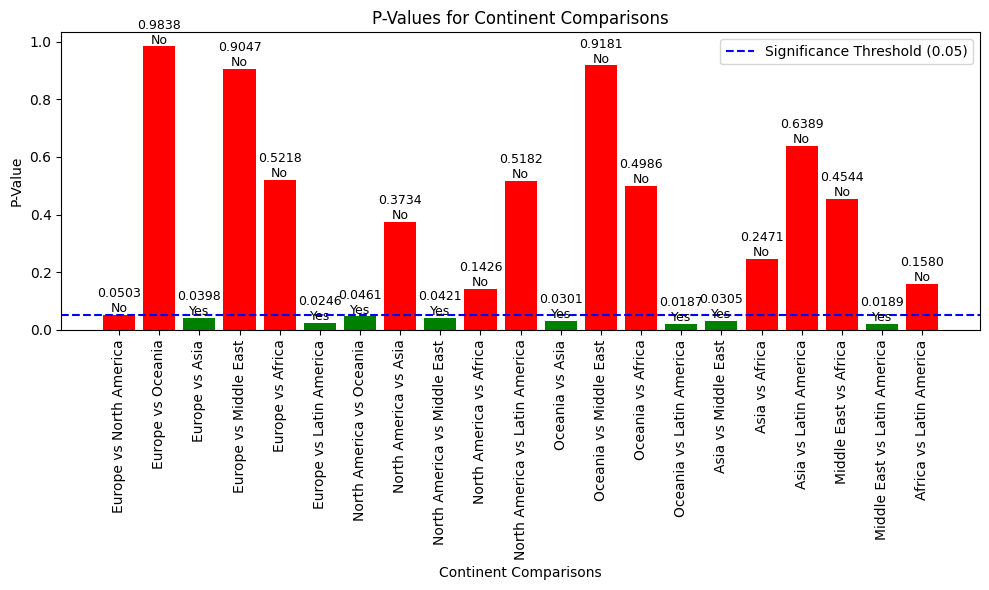

In [55]:
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df['Continent 1'] + " vs " + comparison_df['Continent 2'], 
               comparison_df['P-Value'], 
               color=['green' if sig == 'Yes' else 'red' for sig in comparison_df['Significant']])

plt.axhline(y=0.05, color='blue', linestyle='--', label='Significance Threshold (0.05)')
plt.xlabel('Continent Comparisons')
plt.ylabel('P-Value')
plt.title('P-Values for Continent Comparisons')
plt.legend()

# Add labels for significance and P-Values
for bar, (p_value, sig) in zip(bars, zip(comparison_df['P-Value'], comparison_df['Significant'])):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, 
             f"{p_value:.4f}\n{sig}", ha='center', fontsize=9)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [56]:
import plotly.graph_objects as go
# Create a bar chart
fig = go.Figure()

# Add bars for P-Values
fig.add_trace(go.Bar(
    x=comparison_df['Continent 1'] + " vs " + comparison_df['Continent 2'],
    y=comparison_df['P-Value'],
    marker_color=['#DC3912' if sig == 'No' else '#B6E880' for sig in comparison_df['Significant']],  # Pastel colors
    text=[f"{p:.4f}<br>{sig}" for p, sig in zip(comparison_df['P-Value'], comparison_df['Significant'])],
    textposition='outside',
    name='P-Value'
))

# Add a significance threshold line
fig.add_trace(go.Scatter(
    x=comparison_df['Continent 1'] + " vs " + comparison_df['Continent 2'],
    y=[0.05] * len(comparison_df),
    mode='lines',
    line=dict(color='blue', dash='dash'),
    name='Significance Threshold (0.05)'
))

# Update layout
fig.update_layout(
    title='P-Values for Continent Comparison Z-tests for LLaVA',
    xaxis_title='Continent Comparisons',
    yaxis_title='P-Value',
    xaxis=dict(tickangle=90),
    showlegend=True,
    legend=dict(
        orientation='h',
        x=0.5,
        y=1.05,
        xanchor='center',
        yanchor='bottom'
    ),
    height=700,
    width=800
)

# Show the plot
fig.show()

fig.write_image("llava_continent_ztest.png", width=800, height=700, scale=2)

### OpenClip

#### IMPORTING DATA

In [11]:
file_path = '/Users/kristinafuji/scale-equity-nlp/probs_openclip_zero_shot_group_accuracy_results.json'
with open(file_path, 'r') as file:
    data_open = json.load(file)

#file_path_01 = '/Users/kristinafuji/scale-equity-nlp/probs_finetuned_0.1_open_clip_group_accuracy_results.json'
#with open(file_path_01, 'r') as file:
#    data_open_01 = json.load(file)

In [12]:
# Western vs Non-Western DataFrame
open_western = pd.DataFrame([
    {"Group": "Western", "Correct": data_open["Western"]["correct"], "Total": data_open["Western"]["total"], "Accuracy": data_open["Western"]["accuracy"]},
    {"Group": "Non-Western", "Correct": data_open["Non-Western"]["correct"], "Total": data_open["Non-Western"]["total"], "Accuracy": data_open["Non-Western"]["accuracy"]}
])

# Continents DataFrame
continents_list_open = []
for continent, stats in data_open["Continents"].items():
    continents_list_open.append({
        "Continent": continent,
        "Correct": stats["correct"],
        "Total": stats["total"],
        "Accuracy": stats["accuracy"]
    })

open_continents = pd.DataFrame(continents_list_open)

# Print both DataFrames
print("Western vs Non-Western:")
print(open_western)
print("\nContinents:")
print(open_continents)

# # Western vs Non-Western DataFrame
# western_vs_nonwestern_01 = pd.DataFrame([
#     {"Group": "Western", "Correct": data_open_01["Western"]["correct"], "Total": data_open_01["Western"]["total"], "Accuracy": data_open_01["Western"]["accuracy"]},
#     {"Group": "Non-Western", "Correct": data_open_01["Non-Western"]["correct"], "Total": data_open_01["Non-Western"]["total"], "Accuracy": data_open_01["Non-Western"]["accuracy"]}
# ])

# # Continents DataFrame
# continents_list_01 = []
# for continent, stats in data_open_01["Continents"].items():
#     continents_list_01.append({
#         "Continent": continent,
#         "Correct": stats["correct"],
#         "Total": stats["total"],
#         "Accuracy": stats["accuracy"]
#     })

# continents_df_01 = pd.DataFrame(continents_list_01)

# # Print both DataFrames
# print("Western vs Non-Western:")
# print(western_vs_nonwestern_01)
# print("\nContinents:")
# print(continents_df_01)


Western vs Non-Western:
         Group  Correct  Total   Accuracy
0      Western     2520   2662  94.665665
1  Non-Western     3462   3713  93.239968

Continents:
       Continent  Correct  Total   Accuracy
0         Europe      243    248  97.983871
1  North America       27     29  93.103448
2        Oceania      268    279  96.057348
3           Asia      445    471  94.479830
4    Middle East      233    243  95.884774
5         Africa      172    176  97.727273
6  Latin America      229    240  95.416667


In [14]:
import plotly.graph_objects as go

# Extract data for OpenClip and Fine-Tuned OpenClip 0.1
groups = open_continents['Continent']
openclip_accuracies = open_continents['Accuracy']
fine_tuned_accuracies = continents_df_01['Accuracy']

# Create a bar chart
fig = go.Figure()

# Add bars for OpenClip accuracies
fig.add_trace(go.Bar(
    x=groups,
    y=openclip_accuracies,
    name='OpenClip',
    marker_color='salmon',
    text=[f"{v:.1f}%" for v in openclip_accuracies],
    textposition='outside'
))

# Add bars for Fine-Tuned OpenClip 0.1 accuracies
fig.add_trace(go.Bar(
    x=groups,
    y=fine_tuned_accuracies,
    name='Fine-Tuned OpenClip 0.1',
    marker_color='cornflowerblue',
    text=[f"{v:.1f}%" for v in fine_tuned_accuracies],
    textposition='outside'
))

# Update layout
fig.update_layout(
    title='Accuracies by Continent: OpenClip vs Fine-Tuned OpenClip 0.1',
    xaxis_title='Continent',
    yaxis_title='Accuracy (%)',
    barmode='group',
    xaxis=dict(tickangle=30),
    height=500
)

# Show the plot
fig.show()

NameError: name 'continents_df_01' is not defined

In [13]:
import plotly.graph_objects as go

# Data for the plot
models = ['Open Clip', 'Open Clip Fine-Tuned 0.1']
groups = ['Western', 'Non-Western']
western_accuracies = [accuracies['Open Clip'][0], accuracies['Open Clip Fine-Tuned 0.1'][0]]
non_western_accuracies = [accuracies['Open Clip'][1], accuracies['Open Clip Fine-Tuned 0.1'][1]]

# Create a bar chart
fig = go.Figure()

# Add bars for Western accuracies
fig.add_trace(go.Bar(
    x=models,
    y=western_accuracies,
    name='Western',
    marker_color='cornflowerblue',
    text=[f"{v:.2f}%" for v in western_accuracies],
    textposition='outside'
))

# Add bars for Non-Western accuracies
fig.add_trace(go.Bar(
    x=models,
    y=non_western_accuracies,
    name='Non-Western',
    marker_color='salmon',
    text=[f"{v:.2f}%" for v in non_western_accuracies],
    textposition='outside'
))

# Update layout
fig.update_layout(
    title='Western vs Non-Western Accuracy for Open Clip Models',
    xaxis_title='Models',
    yaxis_title='Accuracy (%)',
    barmode='group',
    height=500
)

# Show the plot
fig.show()

NameError: name 'accuracies' is not defined

Western/Non-Western Accuracy Disparity: 1.14%
Continents Accuracy Disparity: 6.62%


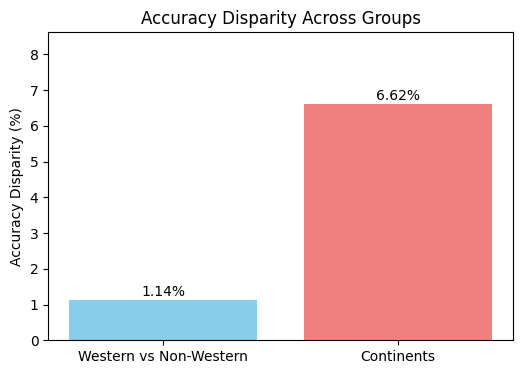

In [18]:
western_disparity = open_western['Accuracy'].max() - open_western['Accuracy'].min()
print(f"Western/Non-Western Accuracy Disparity: {western_disparity:.2f}%")

# Calculate disparity for Continents
continent_disparity = open_continents['Accuracy'].max() - open_continents['Accuracy'].min()
print(f"Continents Accuracy Disparity: {continent_disparity:.2f}%")

# Plotting
disparities = {
    'Western vs Non-Western': western_disparity,
    'Continents': continent_disparity
}

# Plot
plt.figure(figsize=(6,4))
plt.bar(disparities.keys(), disparities.values(), color=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy Disparity (%)')
plt.title('Accuracy Disparity Across Groups')

# Add labels on top of bars
for i, v in enumerate(disparities.values()):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontsize=10)

plt.ylim(0, max(disparities.values()) + 2)
plt.show()

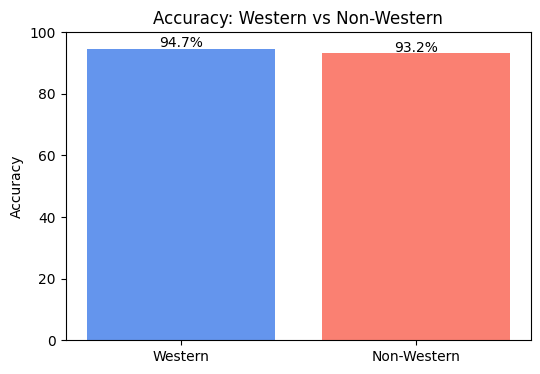

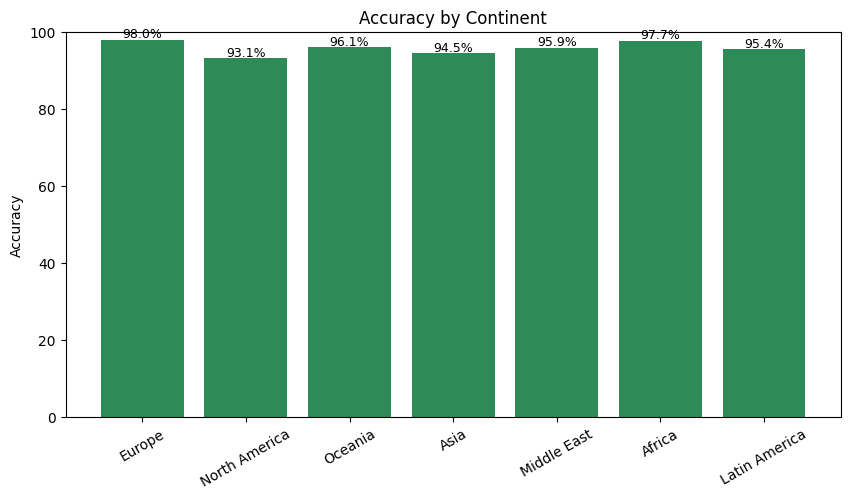

In [15]:
# Western vs Non-Western Accuracy 
tpr_western = open_western[['Group', 'Accuracy']].copy()

# Continents Accuracies
tpr_continents = open_continents[['Continent', 'Accuracy']].copy()

# Plot: Western vs Non-Western Accuracy
plt.figure(figsize=(6,4))
plt.bar(tpr_western['Group'], tpr_western['Accuracy'], color=['cornflowerblue', 'salmon'])
plt.ylabel('Accuracy')
plt.title('Accuracy: Western vs Non-Western')
for i, v in enumerate(tpr_western['Accuracy']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')
plt.ylim(0, 100)
plt.show()

# Plot: Continents TPR
plt.figure(figsize=(10,5))
plt.bar(tpr_continents['Continent'], tpr_continents['Accuracy'], color='seagreen')
plt.ylabel('Accuracy')
plt.title('Accuracy by Continent')
for i, v in enumerate(tpr_continents['Accuracy']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.show()

In [18]:
import plotly.graph_objects as go

# Plot: Western vs Non-Western Accuracy
fig1 = go.Figure()
fig1.add_trace(go.Bar(
    x=tpr_western['Group'],
    y=tpr_western['Accuracy'],
    marker_color=['cornflowerblue', 'salmon'],
    text=[f"{v:.1f}%" for v in tpr_western['Accuracy']],
    textposition='outside'
))
fig1.update_layout(
    title='Accuracy: Western vs Non-Western',
    xaxis_title='Group',
    yaxis_title='Accuracy',
    yaxis=dict(range=[0, 100]),
    height=400
)
fig1.show()

# Plot: Continents TPR
fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=tpr_continents['Continent'],
    y=tpr_continents['Accuracy'],
    marker_color='seagreen',
    text=[f"{v:.1f}%" for v in tpr_continents['Accuracy']],
    textposition='outside'
))
fig2.update_layout(
    title='Accuracy by Continent',
    xaxis_title='Continent',
    yaxis_title='Accuracy',
    xaxis=dict(tickangle=30),
    yaxis=dict(range=[0, 100]),
    height=500
)
fig2.show()

#### Z-TESTS AND PLOTS FOR OPEN

In [88]:
from statsmodels.stats.proportion import proportions_ztest

# Counts of correct answers
correct = open_western['Correct']  # Western, Non-Western

# Total questions per group
total = open_western['Total']

# Two-proportion z-test
z_stat, p_value = proportions_ztest(count=correct, nobs=total)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant difference in accuracy.")
else:
    print("❌ No significant difference.")


Z-statistic: 2.3341
P-value: 0.0196
✅ Statistically significant difference in accuracy.


In [85]:
from itertools import combinations

comparison_results = []

# Iterate through combinations of continents
for continent1, continent2 in combinations(open_continents.iterrows(), 2):
    total_c1 = open_continents['Total'][continent1[0]]
    correct_c1 = open_continents['Correct'][continent1[0]]
    total_c2 = open_continents['Total'][continent2[0]]
    correct_c2 = open_continents['Correct'][continent2[0]]
    z_stat, p_value = proportions_ztest(count=[correct_c1, correct_c2], nobs=[total_c1, total_c2])
    
    # Append the results to the list
    comparison_results.append({
        "Continent 1": continent1[1]['Continent'],
        "Continent 2": continent2[1]['Continent'],
        "Z-Statistic": z_stat,
        "P-Value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

# Convert the list to a DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Display the DataFrame
print(comparison_df)

      Continent 1    Continent 2  Z-Statistic   P-Value Significant
0          Europe  North America     1.584496  0.113081          No
1          Europe        Oceania     1.286581  0.198240          No
2          Europe           Asia     2.198846  0.027889         Yes
3          Europe    Middle East     1.351304  0.176598          No
4          Europe         Africa     0.180623  0.856663          No
5          Europe  Latin America     1.592102  0.111362          No
6   North America        Oceania    -0.752990  0.451456          No
7   North America           Asia    -0.312884  0.754369          No
8   North America    Middle East    -0.689384  0.490582          No
9   North America         Africa    -1.368773  0.171070          No
10  North America  Latin America    -0.548663  0.583237          No
11        Oceania           Asia     0.964210  0.334941          No
12        Oceania    Middle East     0.100089  0.920273          No
13        Oceania         Africa    -0.971604  0

In [58]:
import plotly.graph_objects as go
# Create a bar chart
fig = go.Figure()

# Add bars for P-Values
fig.add_trace(go.Bar(
    x=comparison_df['Continent 1'] + " vs " + comparison_df['Continent 2'],
    y=comparison_df['P-Value'],
    marker_color=['#DC3912' if sig == 'No' else '#B6E880' for sig in comparison_df['Significant']],  # Pastel colors
    text=[f"{p:.4f}<br>{sig}" for p, sig in zip(comparison_df['P-Value'], comparison_df['Significant'])],
    textposition='outside',
    name='P-Value'
))

# Add a significance threshold line
fig.add_trace(go.Scatter(
    x=comparison_df['Continent 1'] + " vs " + comparison_df['Continent 2'],
    y=[0.05] * len(comparison_df),
    mode='lines',
    line=dict(color='blue', dash='dash'),
    name='Significance Threshold (0.05)'
))

# Update layout
fig.update_layout(
    title='P-Values for Continent Comparison Z-tests for OpenCLIP',
    xaxis_title='Continent Comparisons',
    yaxis_title='P-Value',
    xaxis=dict(tickangle=90),
    showlegend=True,
    legend=dict(
        orientation='h',
        x=0.5,
        y=1.05,
        xanchor='center',
        yanchor='bottom'
    ),
    height=700,
    width=800
)

# Show the plot
fig.show()

fig.write_image("open_continent_ztest.png", width=800, height=700, scale=2)

In [86]:
from scipy.stats import chi2_contingency

# Correct answers per continent
correct = open_continents['Correct']

# Incorrect answers per continent
total = open_continents['Total']
incorrect = total - correct

# Contingency table
table = np.array([correct, incorrect])

# Chi-Square test
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-Square: {chi2:.4f}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("✅ Statistically significant difference across continents.")
else:
    print("❌ No significant difference across continents.")


Chi-Square: 7.3994
P-value: 0.2855
❌ No significant difference across continents.


In [87]:
from statsmodels.stats.proportion import proportions_ztest

# Counts of correct answers
correct = western_vs_nonwestern_01['Correct']  # Western, Non-Western

# Total questions per group
total = western_vs_nonwestern_01['Total']

# Two-proportion z-test
z_stat, p_value = proportions_ztest(count=correct, nobs=total)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant difference in accuracy.")
else:
    print("❌ No significant difference.")


NameError: name 'western_vs_nonwestern_01' is not defined

In [70]:
from scipy.stats import chi2_contingency

# Correct answers per continent
correct = continents_df_01['Correct']

# Incorrect answers per continent
total = continents_df_01['Total']
incorrect = total - correct

# Contingency table
table = np.array([correct, incorrect])

# Chi-Square test
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-Square: {chi2:.4f}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("✅ Statistically significant difference across continents.")
else:
    print("❌ No significant difference across continents.")


Chi-Square: 7.3994
P-value: 0.2855
❌ No significant difference across continents.


#### ECE TESTS

In [26]:
import pandas as pd

# Load the JSON files as DataFrames
file_path_results = '/Users/kristinafuji/scale-equity-nlp/probs_openclip_zero_shot_results.json'
#file_path_dataset = '/Users/kristinafuji/scale-equity-nlp/evaluation_dataset.json'

results_df = pd.read_json(file_path_results)
#dataset_df = pd.read_json(file_path_dataset)

# Perform a left join on 'question' and 'image'
#merged_df = pd.merge(dataset_df, results_df, on=['question', 'image'], how='left')

# Display the merged DataFrame
print(results_df)

        id                                           question  \
0        0             Which caption best matches this image?   
1        1  Which of the following best describes this image?   
2        2  Which option is the most accurate label for th...   
3        3                         What does this image show?   
4        4  Which option is the most accurate label for th...   
...    ...                                                ...   
6370  6403                         What is this a picture of?   
6371  6404             Which caption best matches this image?   
6372  6405     Choose the correct description for this image.   
6373  6406                         What is this a picture of?   
6374  6407                 What is the subject of this photo?   

                                                  image  \
0     https://upload.wikimedia.org/wikipedia/commons...   
1     https://upload.wikimedia.org/wikipedia/commons...   
2     https://upload.wikimedia.org/wikiped

In [30]:
# Define the categories
western_categories = {
    "Europe", "North America", "Australia", "New Zealand",
    "Greco-Roman", "Enlightenment", "Christian", "Humanist",
    "Individualism", "Secularism", "Rationalism", "Liberalism", "Democracy",
    "Realism", "Modernism", "Minimalism", "Gothic architecture", "Baroque architecture"
}

non_western_categories = {
    "South Asia", "Southeast Asia", "Middle East", "East Asia", "Africa", "Latin America", "Indigenous Culture",
    "Confucian", "Taoist", "Hindu", "Islamic", "Buddhist", "Animist",
    "Collectivism", "Spirituality", "Tradition", "Hierarchy",
    "Symbolism", "Oral tradition", "Islamic architecture", "Buddhist architecture", "Vernacular architecture"
}

continent_categories = {
    "Europe": {"Europe"},
    "North America": {"North America"},
    "Oceania": {"Australia", "New Zealand"},
    "Asia": {"South Asia", "Southeast Asia", "East Asia"},
    "Middle East": {"Middle East"},
    "Africa": {"Africa"},
    "Latin America": {"Latin America"}
}

# Create the western_vs_nonwestern column
def determine_western_vs_nonwestern(category):
    if category in western_categories:
        return "Western"
    elif category in non_western_categories:
        return "Non-Western"
    else:
        return "Unknown"

results_df['western_vs_nonwestern'] = results_df['category'].apply(determine_western_vs_nonwestern)

# Create the continent column
def determine_continent(category):
    for continent, categories in continent_categories.items():
        if category in categories:
            return continent
    return "Unknown"

results_df['continent'] = results_df['category'].apply(determine_continent)

# Display the updated DataFrame
print(results_df[['category', 'western_vs_nonwestern', 'continent']])

                category western_vs_nonwestern continent
0     Indigenous Culture           Non-Western   Unknown
1     Indigenous Culture           Non-Western   Unknown
2     Indigenous Culture           Non-Western   Unknown
3     Indigenous Culture           Non-Western   Unknown
4     Indigenous Culture           Non-Western   Unknown
...                  ...                   ...       ...
6370           Hierarchy           Non-Western   Unknown
6371           Hierarchy           Non-Western   Unknown
6372           Hierarchy           Non-Western   Unknown
6373           Hierarchy           Non-Western   Unknown
6374           Hierarchy           Non-Western   Unknown

[6375 rows x 3 columns]


In [31]:
results_df.columns

Index(['id', 'question', 'image', 'options', 'model_selection',
       'correct_answer', 'is_correct', 'category', 'probabilities',
       'western_vs_nonwestern', 'continent'],
      dtype='object')

In [32]:
import pandas as pd
import json

# Expand safely
rows = []

for idx, row in results_df.iterrows():
    prob_dict = row['probabilities']
    
    # Check if it's a dictionary
    if isinstance(prob_dict, str):
        try:
            prob_dict = json.loads(prob_dict)
        except json.JSONDecodeError:
            continue  # skip broken JSON rows

    if not isinstance(prob_dict, dict):
        continue  # skip if still not a dict (e.g., float, NaN)

    for key, value in prob_dict.items():
        rows.append({
            'western_vs_nonwestern': row['western_vs_nonwestern'],
            'continent': row['continent'],
            'correct_answer': row['correct_answer'],
            'answer_choice': key,
            'probability': value
        })

# Create the expanded DataFrame
expanded_df = pd.DataFrame(rows)

print(expanded_df)


      western_vs_nonwestern continent  \
0               Non-Western   Unknown   
1               Non-Western   Unknown   
2               Non-Western   Unknown   
3               Non-Western   Unknown   
4               Non-Western   Unknown   
...                     ...       ...   
25491           Non-Western   Unknown   
25492           Non-Western   Unknown   
25493           Non-Western   Unknown   
25494           Non-Western   Unknown   
25495           Non-Western   Unknown   

                                          correct_answer  \
0      Basilica of the Cristo Negro of Esquipulas in ...   
1      Basilica of the Cristo Negro of Esquipulas in ...   
2      Basilica of the Cristo Negro of Esquipulas in ...   
3      Basilica of the Cristo Negro of Esquipulas in ...   
4      Black Christ of Esquipulas at Saint Joseph Cat...   
...                                                  ...   
25491  A simple military organizational hierarchy dep...   
25492  Career-oriented purp

In [33]:
expanded_df

,western_vs_nonwestern,continent,correct_answer,answer_choice,probability
0,Non-Western,Unknown,Basilica of the Cristo Negro of Esquipulas in ...,"Canada Day celebrations in Calgary, Alberta in...",2.488618e-07
1,Non-Western,Unknown,Basilica of the Cristo Negro of Esquipulas in ...,Basilica of the Cristo Negro of Esquipulas in ...,9.999993e-01
2,Non-Western,Unknown,Basilica of the Cristo Negro of Esquipulas in ...,"Illustration of fish weir, designed to guide s...",7.256813e-11
3,Non-Western,Unknown,Basilica of the Cristo Negro of Esquipulas in ...,"Grand Duchess Landa Lakes, Ducal Coronation 2008",4.582012e-07
4,Non-Western,Unknown,Black Christ of Esquipulas at Saint Joseph Cat...,"Canada Day celebrations in Calgary, Alberta in...",8.280812e-05
...,...,...,...,...,...
25491,Non-Western,Unknown,A simple military organizational hierarchy dep...,A simple military organizational hierarchy dep...,9.999998e-01
25492,Non-Western,Unknown,Career-oriented purposes can be diagrammed usi...,Career-oriented purposes can be diagrammed usi...,9.779102e-01
25493,Non-Western,Unknown,Career-oriented purposes can be diagrammed usi...,An illustration of how the levels of the hiera...,1.769580e-02
25494,Non-Western,Unknown,Career-oriented purposes can be diagrammed usi...,Three varieties of autohyponym,3.485650e-04


In [34]:
# Filter out rows where the continent is "Unknown"
continent_expanded_df = expanded_df[expanded_df['continent'] != 'Unknown']

# Display the filtered DataFrame
print(continent_expanded_df)

     western_vs_nonwestern continent  \
120            Non-Western      Asia   
121            Non-Western      Asia   
122            Non-Western      Asia   
123            Non-Western      Asia   
124            Non-Western      Asia   
...                    ...       ...   
6859               Western   Oceania   
6860               Western   Oceania   
6861               Western   Oceania   
6862               Western   Oceania   
6863               Western   Oceania   

                                         correct_answer  \
120                           A music parade in Bhutan.   
121                           A music parade in Bhutan.   
122                           A music parade in Bhutan.   
123                           A music parade in Bhutan.   
124   Bhutanese Buddhist monk looking out the window...   
...                                                 ...   
6859  Alf's Imperial Army march to battle the Green ...   
6860  Green Party Forces march to battle Alf's 

In [ ]:
import pandas as pd
import numpy as np

def compute_ece(probs, correct, n_bins=10):
    probs = np.array(probs)
    correct = np.array(correct)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (probs > bin_lower) & (probs <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            acc_in_bin = np.mean(correct[in_bin])
            avg_conf_in_bin = np.mean(probs[in_bin])
            ece += np.abs(avg_conf_in_bin - acc_in_bin) * prop_in_bin
    return ece

# --- dataframe is already prepared like this:
# columns: ['western_vs_nonwestern', 'continent', 'correct_answer', 'answer_choice', 'probability']

# --- Pick the predicted choice (max probability) per question

# If there's no unique ID per question, we assume (correct_answer, group) identifies a question
# Otherwise you'd need a question ID column

w_predicted_df = expanded_df.loc[expanded_df.groupby(['correct_answer', 'western_vs_nonwestern'])['probability'].idxmax()]
c_predicted_df = continent_expanded_df.loc[continent_expanded_df.groupby(['correct_answer', 'continent'])['probability'].idxmax()]
# predicted_df now has 1 row per question, with highest-probability prediction

# Create a column for whether the prediction was correct
w_predicted_df['is_correct'] = (w_predicted_df['answer_choice'] == w_predicted_df['correct_answer']).astype(int)
c_predicted_df['is_correct'] = (c_predicted_df['answer_choice'] == c_predicted_df['correct_answer']).astype(int)
# --- Groupwise ECE Calculation

w_groups = w_predicted_df['western_vs_nonwestern'].dropna().unique().tolist() 
c_groups = c_predicted_df['continent'].dropna().unique().tolist()


ece_results = {}

for g in w_groups:
    if g in w_predicted_df['western_vs_nonwestern'].values:
        df_group = w_predicted_df[w_predicted_df['western_vs_nonwestern'] == g]

    probs = df_group['probability'].tolist()
    correct = df_group['is_correct'].tolist()

    ece = compute_ece(probs, correct, n_bins=10)
    ece_results[g] = ece

for g in c_groups:
    if g in c_predicted_df['continent'].values:
        df_group = c_predicted_df[c_predicted_df['continent'] == g]

    probs = df_group['probability'].tolist()
    correct = df_group['is_correct'].tolist()

    ece = compute_ece(probs, correct, n_bins=10)
    ece_results[g] = ece

# --- Display nicely
for group, ece in ece_results.items():
    print(f"{group}: ECE = {ece:.4f}")


Non-Western: ECE = 0.0194
Western: ECE = 0.0175
Asia: ECE = 0.0362
Middle East: ECE = 0.0258
North America: ECE = 0.0720
Oceania: ECE = 0.0199
Europe: ECE = 0.0139
Latin America: ECE = 0.0389
Africa: ECE = 0.0157


In [41]:
import plotly.graph_objects as go

# Prepare data for the plot
groups = list(ece_results.keys())
ece_values = list(ece_results.values())

# Create a bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=groups,
    y=ece_values,
    marker_color='cornflowerblue',
    text=[f"{v:.4f}" for v in ece_values],
    textposition='outside',
    name='ECE'
))

# Update layout
fig.update_layout(
    title='Expected Calibration Error (ECE) by Group for OpenCLIP',
    xaxis_title='Groups',
    yaxis_title='ECE',
    yaxis=dict(range=[0, max(ece_values) + 0.01]),
    height=500,
    width=800
)

# Show the plot
fig.show()
fig.write_image("open_ece.png", width=800, height=500, scale=2)

### Smol

#### IMPORTING DATA

In [42]:
file_path = '/Users/kristinafuji/scale-equity-nlp/smolvlm_group_accuracy_results_all.json'
with open(file_path, 'r') as file:
    data_smol = json.load(file)

In [43]:
# Western vs Non-Western DataFrame
smol_western = pd.DataFrame([
    {"Group": "Western", "Correct": data_smol["Western"]["correct"], "Total": data_smol["Western"]["total"], "Accuracy": data_smol["Western"]["accuracy"]},
    {"Group": "Non-Western", "Correct": data_smol["Non-Western"]["correct"], "Total": data_smol["Non-Western"]["total"], "Accuracy": data_smol["Non-Western"]["accuracy"]}
])

# Continents DataFrame
continents_list_smol = []
for continent, stats in data_smol["Continents"].items():
    continents_list_smol.append({
        "Continent": continent,
        "Correct": stats["correct"],
        "Total": stats["total"],
        "Accuracy": stats["accuracy"]
    })

smol_continents = pd.DataFrame(continents_list_smol)

# Print both DataFrames
print("Western vs Non-Western:")
print(smol_western)
print("\nContinents:")
print(smol_continents)

Western vs Non-Western:
         Group  Correct  Total   Accuracy
0      Western     2114   2649  79.803700
1  Non-Western     2923   3694  79.128316

Continents:
       Continent  Correct  Total   Accuracy
0         Europe      221    248  89.112903
1  North America       22     29  75.862069
2        Oceania      254    278  91.366906
3           Asia      411    470  87.446809
4    Middle East      214    243  88.065844
5         Africa      157    172  91.279070
6  Latin America      203    240  84.583333


Western/Non-Western Accuracy Disparity: 0.68%
Continents Accuracy Disparity: 15.50%


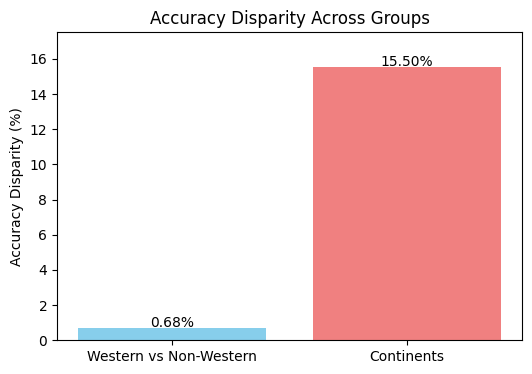

In [44]:
western_disparity = smol_western['Accuracy'].max() - smol_western['Accuracy'].min()
print(f"Western/Non-Western Accuracy Disparity: {western_disparity:.2f}%")

# Calculate disparity for Continents
continent_disparity = smol_continents['Accuracy'].max() - smol_continents['Accuracy'].min()
print(f"Continents Accuracy Disparity: {continent_disparity:.2f}%")

# Plotting
disparities = {
    'Western vs Non-Western': western_disparity,
    'Continents': continent_disparity
}

# Plot
plt.figure(figsize=(6,4))
plt.bar(disparities.keys(), disparities.values(), color=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy Disparity (%)')
plt.title('Accuracy Disparity Across Groups')

# Add labels on top of bars
for i, v in enumerate(disparities.values()):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontsize=10)

plt.ylim(0, max(disparities.values()) + 2)
plt.show()

#### Z-TESTS AND PLOTS FOR SMOL

In [46]:
from statsmodels.stats.proportion import proportions_ztest

# Counts of correct answers
correct = smol_western['Correct']  # Western, Non-Western

# Total questions per group
total = smol_western['Total']

# Two-proportion z-test
z_stat, p_value = proportions_ztest(count=correct, nobs=total)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant difference in accuracy.")
else:
    print("❌ No significant difference.")


Z-statistic: 0.6560
P-value: 0.5118
❌ No significant difference.


In [47]:
from scipy.stats import chi2_contingency

# Correct answers per continent
correct = smol_continents['Correct']

# Incorrect answers per continent
total = smol_continents['Total']
incorrect = total - correct

# Contingency table
table = np.array([correct, incorrect])

# Chi-Square test
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-Square: {chi2:.4f}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("✅ Statistically significant difference across continents.")
else:
    print("❌ No significant difference across continents.")


Chi-Square: 11.9749
P-value: 0.0625
❌ No significant difference across continents.


In [59]:
from itertools import combinations

comparison_results = []

# Iterate through combinations of continents
for continent1, continent2 in combinations(smol_continents.iterrows(), 2):
    total_c1 = smol_continents['Total'][continent1[0]]
    correct_c1 = smol_continents['Correct'][continent1[0]]
    total_c2 = smol_continents['Total'][continent2[0]]
    correct_c2 = smol_continents['Correct'][continent2[0]]
    z_stat, p_value = proportions_ztest(count=[correct_c1, correct_c2], nobs=[total_c1, total_c2])
    
    # Append the results to the list
    comparison_results.append({
        "Continent 1": continent1[1]['Continent'],
        "Continent 2": continent2[1]['Continent'],
        "Z-Statistic": z_stat,
        "P-Value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

# Convert the list to a DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Display the DataFrame
print(comparison_df)



      Continent 1    Continent 2  Z-Statistic   P-Value Significant
0          Europe  North America     2.057621  0.039627         Yes
1          Europe        Oceania    -0.872095  0.383157          No
2          Europe           Asia     0.653776  0.513256          No
3          Europe    Middle East     0.364924  0.715168          No
4          Europe         Africa    -0.727673  0.466814          No
5          Europe  Latin America     1.481922  0.138361          No
6   North America        Oceania    -2.637075  0.008362         Yes
7   North America           Asia    -1.787181  0.073908          No
8   North America    Middle East    -1.833047  0.066796          No
9   North America         Africa    -2.459933  0.013896         Yes
10  North America  Latin America    -1.199341  0.230395          No
11        Oceania           Asia     1.649564  0.099032          No
12        Oceania    Middle East     1.243476  0.213693          No
13        Oceania         Africa     0.032182  0

In [60]:
import plotly.graph_objects as go
# Create a bar chart
fig = go.Figure()

# Add bars for P-Values
fig.add_trace(go.Bar(
    x=comparison_df['Continent 1'] + " vs " + comparison_df['Continent 2'],
    y=comparison_df['P-Value'],
    marker_color=['#DC3912' if sig == 'No' else '#B6E880' for sig in comparison_df['Significant']],  # Pastel colors
    text=[f"{p:.4f}<br>{sig}" for p, sig in zip(comparison_df['P-Value'], comparison_df['Significant'])],
    textposition='outside',
    name='P-Value'
))

# Add a significance threshold line
fig.add_trace(go.Scatter(
    x=comparison_df['Continent 1'] + " vs " + comparison_df['Continent 2'],
    y=[0.05] * len(comparison_df),
    mode='lines',
    line=dict(color='blue', dash='dash'),
    name='Significance Threshold (0.05)'
))

# Update layout
fig.update_layout(
    title='P-Values for Continent Comparison Z-tests for SmolVLM',
    xaxis_title='Continent Comparisons',
    yaxis_title='P-Value',
    xaxis=dict(tickangle=90),
    showlegend=True,
    legend=dict(
        orientation='h',
        x=0.5,
        y=1.05,
        xanchor='center',
        yanchor='bottom'
    ),
    height=700,
    width=800
)

# Show the plot
fig.show()

fig.write_image("smol_continent_ztest.png", width=800, height=700, scale=2)

## Figures with All Models

In [74]:
# Prepare data for plotting
models = ['Smol', 'Open Clip', 'LLaVA']
continents = smol_continents['Continent']
smol_accuracies = smol_continents['Accuracy']
open_accuracies = open_continents['Accuracy']
llava_accuracies = llava_continents['Accuracy']

# Create a bar chart
fig = go.Figure()

# Add bars for each model
fig.add_trace(go.Bar(
    x=continents,
    y=smol_accuracies,
    name='SmolVLM',
    marker_color='lightpink',
    text=[f"{v:.1f}%" for v in smol_accuracies],  # Add percentages
    textposition='outside'
))
fig.add_trace(go.Bar(
    x=continents,
    y=llava_accuracies,
    name='LLaVA',
    marker_color='cornflowerblue',
    text=[f"{v:.1f}%" for v in llava_accuracies],  # Add percentages
    textposition='outside'
))
fig.add_trace(go.Bar(
    x=continents,
    y=open_accuracies,
    name='OpenCLIP',
    marker_color='slateblue',
    text=[f"{v:.1f}%" for v in open_accuracies],  # Add percentages
    textposition='outside'
))

# Update layout
fig.update_layout(
    title='Model Accuracies by Continent',
    xaxis_title='Continent',
    yaxis_title='Accuracy (%)',
    barmode='group',
    xaxis=dict(tickangle=30),
    height=500,
    width=800
)

# Show the plot
fig.show()

fig.write_image("model_accuracy_comparison.png", width=800, height=500, scale=2)

In [75]:
# Prepare data for plotting
models = ['Smol', 'Open Clip', 'LLaVA']
group = smol_western['Group']
smol_accuracies = smol_western['Accuracy']
open_accuracies = open_western['Accuracy']
llava_accuracies = llava_western['Accuracy']

# Create a bar chart
fig = go.Figure()

# Add bars for each model
fig.add_trace(go.Bar(
    x=group,
    y=smol_accuracies,
    name='SmolVLM',
    marker_color='lightpink',
    text=[f"{v:.1f}%" for v in smol_accuracies],  # Add percentages
    textposition='outside'
))
fig.add_trace(go.Bar(
    x=group,
    y=llava_accuracies,
    name='LLaVA',
    marker_color='cornflowerblue',
    text=[f"{v:.1f}%" for v in llava_accuracies],  # Add percentages
    textposition='outside'
))
fig.add_trace(go.Bar(
    x=group,
    y=open_accuracies,
    name='OpenCLIP',
    marker_color='slateblue',
    text=[f"{v:.1f}%" for v in open_accuracies],  # Add percentages
    textposition='outside'
))

# Update layout
fig.update_layout(
    title='Model Accuracies by Western vs Non-Western',
    xaxis_title='Group',
    yaxis_title='Accuracy (%)',
    barmode='group',
    xaxis=dict(tickangle=30),
    height=500,
    width=800
)

# Show the plot
fig.show()

fig.write_image("model_accuracy_western.png", width=800, height=500, scale=2)

In [83]:

# Calculate disparities for all 3 models
disparities = {
    'Western vs Non-Western': {
        'SmolVLM': smol_western['Accuracy'].max() - smol_western['Accuracy'].min(),
        'LLaVA': llava_western['Accuracy'].max() - llava_western['Accuracy'].min(),
        'OpenCLIP': open_western['Accuracy'].max() - open_western['Accuracy'].min()
        
    },
    'Continents': {
        'SmolVLM': smol_continents['Accuracy'].max() - smol_continents['Accuracy'].min(),
        'LLaVA': llava_continents['Accuracy'].max() - llava_continents['Accuracy'].min(),
        'OpenCLIP': open_continents['Accuracy'].max() - open_continents['Accuracy'].min()
        
    }
}

# Prepare data for Plotly
categories = list(disparities.keys())
models = list(disparities['Western vs Non-Western'].keys())
data = []

for category in categories:
    for model in models:
        data.append({
            'Category': category,
            'Model': model,
            'Disparity': disparities[category][model]
        })

# Convert to DataFrame for easier plotting
disparity_df = pd.DataFrame(data)

# Plot using Plotly
fig = px.bar(
    disparity_df,
    x='Category',
    y='Disparity',
    color='Model',
    barmode='group',
    text='Disparity',
    title='Accuracy Disparity for Western vs Non-Western and Continents Across Models',
    labels={'Disparity': 'Accuracy Disparity (%)'},
    color_discrete_map={
        'SmolVLM': 'lightpink',
        'LLaVA': 'cornflowerblue',     
        'OpenCLIP': 'slateblue'    
    }
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(
    xaxis_title='Category',
    yaxis_title='Accuracy Disparity (%)',
    height=500,
    width=800
)

fig.show()

fig.write_image("model_accuracy_disparity.png", width=800, height=500, scale=2)